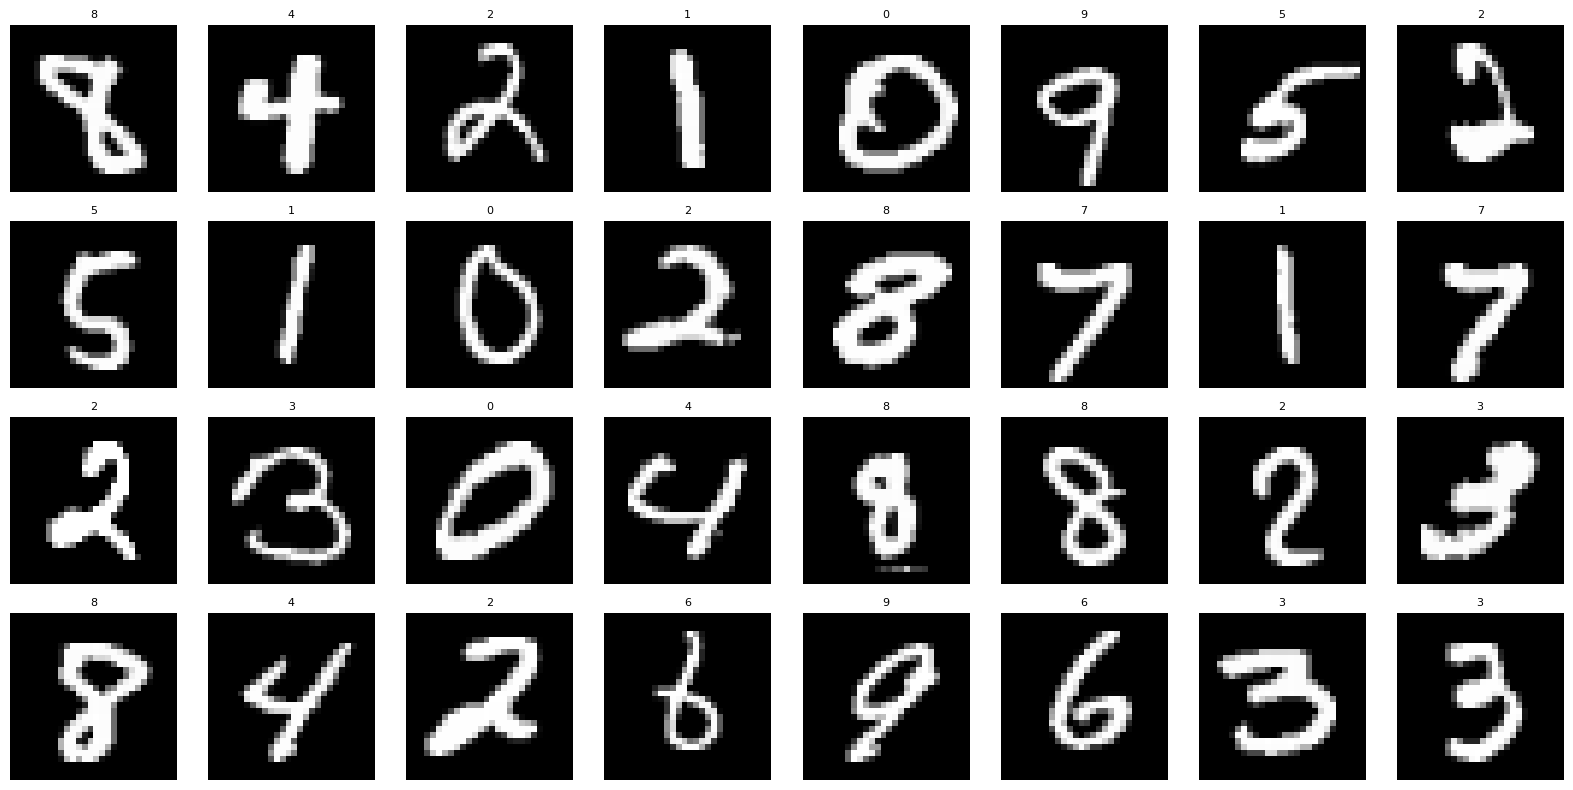

In [14]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Define transformation: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten the image to 1D
])

# Download and load MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoader objects
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Show a batch of training images and their labels
examples = next(iter(train_loader))
images, labels = examples

# Reshape flattened images back to 28x28 for visualization
images_reshaped = images.view(-1, 1, 28, 28)


# Plot all 32 images in an 8x4 grid
plt.figure(figsize=(16, 8))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    plt.imshow(images_reshaped[i][0], cmap='gray')
    plt.title(f'{labels[i].item()}', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
import torch.nn as nn

class LinearClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LinearClassifier, self).__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

In [16]:
criterion = nn.CrossEntropyLoss()

Epoch 1: Train Loss=3.8612, Train Acc=0.4016, Val Loss=3.8860, Val Acc=0.3965
Epoch 2: Train Loss=4.2591, Train Acc=0.4669, Val Loss=4.1791, Val Acc=0.4667
Epoch 3: Train Loss=4.6051, Train Acc=0.5229, Val Loss=4.5911, Val Acc=0.5201
Epoch 4: Train Loss=5.0076, Train Acc=0.5297, Val Loss=4.8448, Val Acc=0.5387
Epoch 5: Train Loss=4.8889, Train Acc=0.5811, Val Loss=4.6433, Val Acc=0.5936
Epoch 6: Train Loss=4.6651, Train Acc=0.6229, Val Loss=4.4539, Val Acc=0.6332
Epoch 7: Train Loss=5.2545, Train Acc=0.6133, Val Loss=4.9540, Val Acc=0.6255
Epoch 8: Train Loss=5.1286, Train Acc=0.6416, Val Loss=4.7398, Val Acc=0.6579
Epoch 9: Train Loss=5.0165, Train Acc=0.6704, Val Loss=4.5185, Val Acc=0.6858
Epoch 10: Train Loss=5.4589, Train Acc=0.6699, Val Loss=4.8492, Val Acc=0.6876
Epoch 11: Train Loss=5.4887, Train Acc=0.6875, Val Loss=4.9375, Val Acc=0.6988
Epoch 12: Train Loss=5.8536, Train Acc=0.6772, Val Loss=5.3221, Val Acc=0.6889
Epoch 13: Train Loss=5.8952, Train Acc=0.6772, Val Loss=5.402

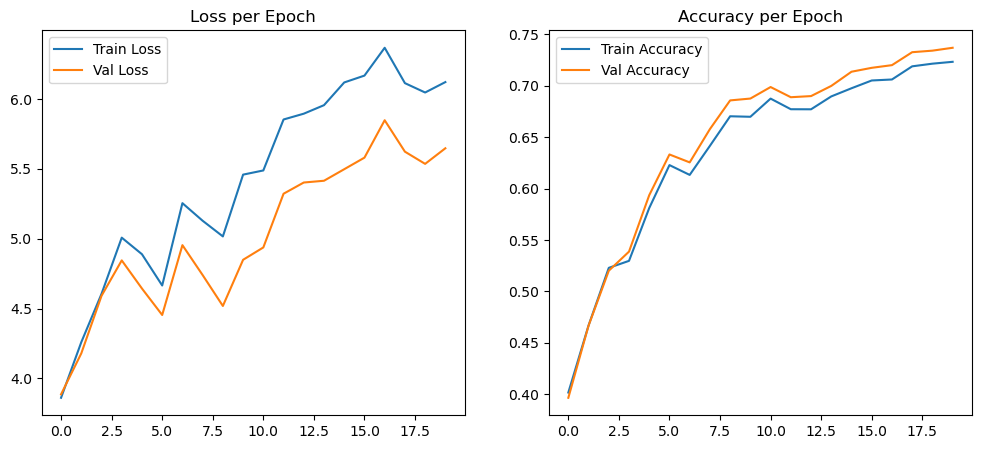

In [17]:
import torch.optim as optim
import numpy as np

# Initialize model, optimizer
input_dim = 784
num_classes = 10
model = LinearClassifier(input_dim, num_classes)
best_model = LinearClassifier(input_dim, num_classes)
best_model.load_state_dict(model.state_dict())  # Copy initial weights

learning_rate = 0.01
epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

def evaluate(loader, model):
    correct = 0
    total = 0
    loss_total = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_total += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return loss_total / len(loader), correct / total

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        # Random perturbation
        with torch.no_grad():
            original_weights = model.linear.weight.clone()
            original_bias = model.linear.bias.clone()

            perturb_weights = torch.randn_like(model.linear.weight) * learning_rate
            perturb_bias = torch.randn_like(model.linear.bias) * learning_rate

            model.linear.weight += perturb_weights
            model.linear.bias += perturb_bias

            outputs = model(images)
            loss = criterion(outputs, labels)

            # If loss doesn't improve, revert
            outputs_original = best_model(images)
            loss_original = criterion(outputs_original, labels)

            if loss.item() < loss_original.item():
                best_model.load_state_dict(model.state_dict())
            else:
                model.linear.weight.data.copy_(original_weights)
                model.linear.bias.data.copy_(original_bias)

    # Evaluate
    train_loss, train_acc = evaluate(train_loader, model)
    val_loss, val_acc = evaluate(test_loader, model)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

# Plot losses and accuracies
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss per Epoch')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()
plt.title('Accuracy per Epoch')
plt.show()

In [18]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Save model
torch.save(best_model.state_dict(), "best_linear_model.pth")

# Evaluate on test set
y_true = []
y_pred = []

best_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = best_model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.tolist())
        y_pred.extend(predicted.tolist())

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
conf_matrix = confusion_matrix(y_true, y_pred)

print(f"Test Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

Test Accuracy: 0.7370
Precision: 0.7379
Recall: 0.7349
F1 Score: 0.7353
Confusion Matrix:
[[863   3  11   7   7  26  16  14  30   3]
 [  0 954  29  26  11   8   2   8  64  33]
 [ 34  34 687  32  76   6  51  21  74  17]
 [ 17  13  34 753   4 102  18  15  34  20]
 [ 13   1   3  14 716  17  29  28  41 120]
 [ 35  15  11  58  57 555  20  24 105  12]
 [ 22   5  31   1  66  49 739   7  32   6]
 [  7  34  43  61  10  11   6 749  15  92]
 [ 16  14  33  54  47  69  21  27 647  46]
 [ 17   7   5  39  72  38   9  62  53 707]]
